In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random
import os
import tensorflow
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import math
import seaborn as sns
import math
# Load data
df = pd.read_csv("FourRegionData.csv")
df.tail(10)

,Region,Year,Month,SoilTemperature-10,SoilTemperature-30,SoilTemperature-50,Rainfall,Temperature,Min Temperature,Max Temperature,Humidity,Sunshine,Wind Speed,Surface Pressure,Solar Radiation
1046,7,2022,3,27.59,26.70,24.56,0,27.00,20.57,33.43,76.87,7.65,2.44,100825.01,252.13
1047,7,2022,4,30.10,29.31,27.17,101,29.60,25.00,34.20,77.03,4.31,3.13,100602.19,218.59
1048,7,2022,5,29.86,29.48,27.54,313,28.90,24.68,33.12,78.55,4.58,2.58,100286.95,203.23
1049,7,2022,6,30.45,30.02,28.05,235,29.73,26.00,33.47,76.73,2.84,3.34,100167.14,170.59
1050,7,2022,7,32.03,31.60,29.75,105,30.81,27.15,34.47,77.65,5.82,2.74,100209.10,201.67
1051,7,2022,8,31.46,31.10,29.23,208,30.31,26.57,34.04,78.00,5.54,2.87,100213.52,191.49
1052,7,2022,9,30.54,30.39,28.60,309,29.55,26.05,33.05,76.63,3.40,2.04,100513.85,166.55
1053,7,2022,10,28.42,28.60,27.11,306,28.20,23.99,32.41,77.52,6.66,1.96,100949.97,175.90
1054,7,2022,11,25.09,25.50,24.31,0,24.52,18.48,30.56,78.20,8.36,1.82,101196.48,185.67
1055,7,2022,12,21.63,21.92,20.77,9,20.72,14.92,26.51,76.71,6.46,1.78,101287.57,169.25


In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    tensorflow.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [3]:



features = df[['Temperature', 'Min Temperature',
               'Max Temperature','Surface Pressure', 'Month', 'Year', 'Wind Speed', 'Sunshine', 'Humidity', 
               'Rainfall']]
target = df['SoilTemperature-30']

n = len(features)
split_idx = int(n * 0.8)

X_train = features[:split_idx]
X_test = features[split_idx:]

y_train = target[:split_idx]
y_test = target[split_idx:]



In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define models in a dictionary
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}


resultss = {}


for name, model in models.items():
    model.fit(X_train, y_train)                         
    y_pred = model.predict(X_test)                       
    mse = (mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)                        
    resultss[name] = {'RMSE': mse**0.5, 'R²': r2}             


for name, metrics in resultss.items():
    print(f"{name}:")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  R²:   {metrics['R²']:.4f}")
    print("-" * 30)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1968
[LightGBM] [Info] Number of data points in the train set: 844, number of used features: 10
[LightGBM] [Info] Start training from score 26.676149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Random Forest:
  RMSE: 1.1741
  R²:   0.9025
------------------------------
Gradient Boosting:
  RMSE: 1.3288
  R²:   0.8752
------------------------------
LightGBM:
  RMSE: 1.2932
  R²:   0.8817
------------------------------
XGBoost:
  RMSE: 1.4156
  R²:   0.8583
------------------------------


In [5]:
f_model=models["Random Forest"]

C:\Users\HP Laptop 15\tfenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_23332\1142960003.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


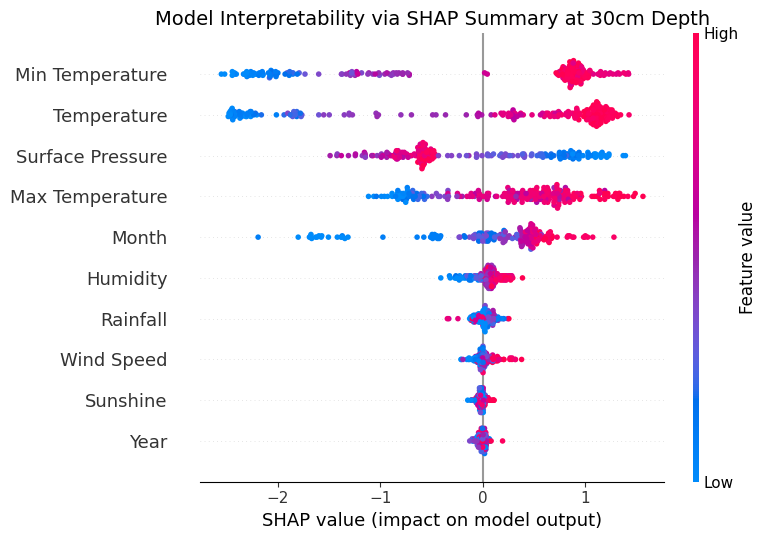

In [6]:

import shap
explainer = shap.TreeExplainer(f_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Model Interpretability via SHAP Summary at 30cm Depth', fontsize=14)
plt.tight_layout()
plt.savefig("Shap-summary-30cm.png", dpi=300)
plt.show()

In [7]:
# plot the SHAP values for the 10th observation 

shap.initjs()
shap.force_plot(explainer.expected_value,shap_values[10,:], X_test.iloc[10,:]) 

In [8]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X_test)

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_23332\1402092520.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


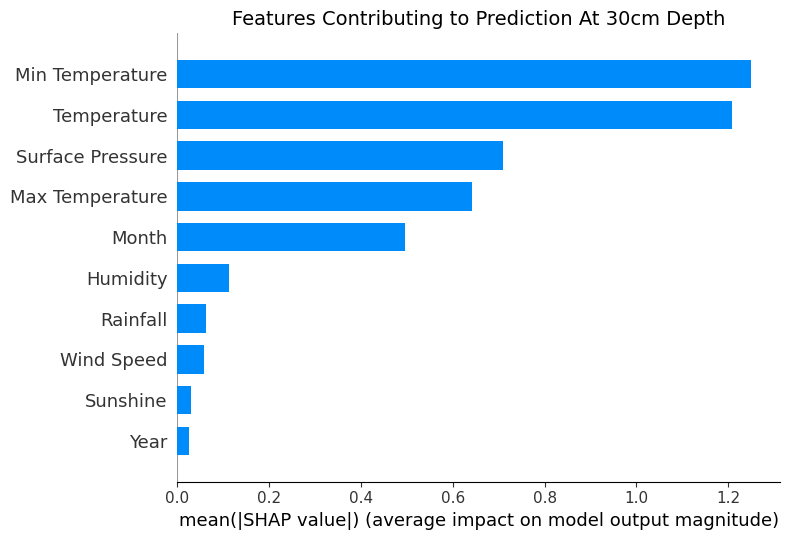

In [9]:


features=['Temperature', 'Min Temperature',
               'Max Temperature','Surface Pressure', 'Month', 'Year', 'Wind Speed', 'Sunshine', 'Humidity', 
               'Rainfall']
shap.summary_plot(
    shap_values,
    max_display=10,
    show=False,
    plot_type='bar',
    feature_names=features
)
plt.title('Features Contributing to Prediction At 30cm Depth', fontsize=14)
plt.tight_layout()
plt.savefig("Shap-summary-plot-30cm.png", dpi=300)
plt.show()

In [10]:
def set_seed(seed=42):
    np.random.seed(seed)
    tensorflow.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

X=df[['Min Temperature','Temperature', 'Surface Pressure',
               'Max Temperature', 'Month']]
y=df['SoilTemperature-30']
# Split the data into training and testing sets
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42)

f_model=RandomForestRegressor(n_estimators=100,random_state=42)
f_model.fit(X_tr, y_tr)

# Make predictions on the test data
y_pr = f_model.predict(X_te)

# Evaluate the model
msee = mean_squared_error(y_te, y_pr)
rr2 = r2_score(y_te, y_pr)

print("Root Mean Squared Error:", msee**0.5)
print("R-squared:", rr2)



Root Mean Squared Error: 1.1918645107086587
R-squared: 0.9090575906982477


In [11]:
def set_seed(seed=42):
    np.random.seed(seed)
    tensorflow.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# --- Preprocessing ---
features = df[['Min Temperature']]
target = df['SoilTemperature-30']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# --- Sliding Window Function ---
def create_sliding_window(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

# --- Loop over different window sizes ---
histories=[]
comparisons={}
window_sizes = [12]
for WINDOW in window_sizes:
    print(f"\n======================")
    print(f"🔁 Training with WINDOW SIZE: {WINDOW}")
    print(f"======================")

    # Create windowed sequences
    X_seq, y_seq = create_sliding_window(X_scaled, y_scaled, WINDOW)

    # Split the data
    total_samples = len(X_seq)
    train_end = int(0.7 * total_samples)
    val_end = int(0.85 * total_samples)

    X_train, y_train = X_seq[:train_end], y_seq[:train_end]
    X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
    X_test, y_test = X_seq[val_end:], y_seq[val_end:]

    # --- Model Definition ---
    model = Sequential([
      LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
      Dropout(0.2),
      LSTM(32, return_sequences=True),
      Dropout(0.2),
      LSTM(32, return_sequences=False),
      Dense(64, activation='relu'),
      Dropout(0.2),
      Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    # --- Callbacks ---
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f'best_model_window_{WINDOW}.h5', monitor='val_loss', save_best_only=True, mode='min')
    lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

    # --- Train the Model ---
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, checkpoint, lr_sched],
        verbose=0
    )
    histories.append(history.history)
    # --- Evaluate ---
    results = model.evaluate(X_test, y_test, verbose=0)
    loss = results[0]
    mae = results[1]
    print(f"✅ Test Loss (RMSE): {np.sqrt(loss):.4f}")
    print(f"✅ Test MAE:       {mae:.4f}")

    # --- Predict and Compare ---
    predictions = model.predict(X_test)
    predictions_rescaled = target_scaler.inverse_transform(predictions)
    y_test_rescaled = target_scaler.inverse_transform(y_test.reshape(-1, 1))
    # === 📊 Extra Evaluation Metrics ===
    y_true = y_test_rescaled.flatten()
    y_pred = predictions_rescaled.flatten()
    r2 = r2_score(y_true, y_pred)
    print(f"✅ R²:       {r2:.4f}") 




🔁 Training with WINDOW SIZE: 12





C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Test Loss (RMSE): 0.0707
✅ Test MAE:       0.0573
5/5 [==============================] - 1s 4ms/step
✅ R²:       0.9061


In [13]:
Depth-30cm

'Min Temperature'
✅ Test Loss (RMSE): 0.0707
✅ Test MAE:       0.0573
5/5 [==============================] - 1s 9ms/step
✅ R²:       0.9061

'Min Temperature','Temperature'
✅ Test Loss (RMSE): 0.0773
✅ Test MAE:       0.0576
5/5 [==============================] - 1s 5ms/step
✅ R²:       0.8879

'Min Temperature','Temperature', 'Surface Pressure'
✅ Test Loss (RMSE): 0.0903
✅ Test MAE:       0.0650
5/5 [==============================] - 1s 4ms/step
✅ R²:       0.8469


'Min Temperature','Temperature', 'Surface Pressure','Max Temperature'
✅ Test Loss (RMSE): 0.0874
✅ Test MAE:       0.0634
5/5 [==============================] - 1s 6ms/step
✅ R²:       0.8567

'Min Temperature','Temperature', 'Surface Pressure','Max Temperature', 'Month'
 Test Loss (RMSE): 0.0764
✅ Test MAE:       0.0584
5/5 [==============================] - 1s 7ms/step
✅ R²:       0.8905